# 06 — Résonance algorithmique : l'effet Larsen informationnel

Une fausse information et un algorithme de recommandation forment une boucle de
rétroaction positive, structurellement identique à l'effet Larsen : approchez un
micro d'un haut-parleur, et le moindre bruit est capté, amplifié, réémis, capté de
nouveau, jusqu'au sifflement.

$$\ddot{V} + \big(\lambda - \gamma\alpha\,\sigma(V)\big)\dot{V} + \omega_0^2 V = \xi(t)$$

avec $\lambda$ l'amortissement naturel (l'oubli), $\gamma$ le gain algorithmique,
$\alpha$ la charge émotionnelle du contenu, et $\sigma(V)$ un facteur de saturation.

**Critère d'instabilité : $\gamma\alpha > \lambda$.** L'amortissement effectif
devient négatif — le système n'évacue plus l'énergie qu'on lui injecte, il
l'accumule. C'est le résultat central, et le seul du projet qui se traduise en une
inégalité auditable sur des paramètres qu'une plateforme connaît.

## Deux corrections au modèle du fil

**Signe du rappel.** Le fil écrivait $-\omega_0^2 V$, ce qui rend le point
d'équilibre instable *quels que soient* les autres paramètres : le système
divergerait même à gain nul, et le critère $\gamma\alpha > \lambda$ perdrait tout
contenu. Le rappel d'un oscillateur s'écrit $+\omega_0^2 V$.

**Saturation.** Sans $\sigma(V)$, la solution instable est
$V(t) \propto e^{(\gamma\alpha - \lambda)t}$ — une divergence sans limite. Or
l'attention disponible est finie. Avec
$\sigma(V) = 1/(1 + (V/V_{\mathrm{sat}})^2)$, le système ne diverge plus : il
s'installe dans un **cycle limite**, une oscillation médiatique auto-entretenue
d'amplitude finie. C'est ce que l'on observe réellement — un sujet qui revient
périodiquement, non une explosion.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ide.plotting import PALETTE, save_figure, use_project_style
from ide.resonance import ResonanceParameters, simulate_resonance

use_project_style()

DAMPING, EMOTION = 0.2, 0.5

regimes = {
    "amorti  ($\\gamma\\alpha < \\lambda$)": ResonanceParameters(
        damping=1.0, gain=0.5, emotion=EMOTION, saturation=1.0
    ),
    "résonant saturé": ResonanceParameters(
        damping=DAMPING, gain=3.0, emotion=EMOTION, saturation=1.0
    ),
    "résonant non borné (modèle du fil)": ResonanceParameters(
        damping=DAMPING, gain=3.0, emotion=EMOTION, saturation=None
    ),
}

solutions = {
    label: simulate_resonance(parameters, total_time=120.0)
    for label, parameters in regimes.items()
}

for label, solution in solutions.items():
    flag = "DIVERGE" if solution.diverged else f"amplitude finale {solution.late_amplitude():.2f}"
    print(f"{label:36s} instable={solution.parameters.is_unstable}  {flag}")

amorti  ($\gamma\alpha < \lambda$)   instable=False  amplitude finale 0.00
résonant saturé                      instable=True  amplitude finale 13.97
résonant non borné (modèle du fil)   instable=True  DIVERGE


## Balayage du gain algorithmique

On fait varier $\gamma$ à $\lambda$ et $\alpha$ fixés. Le seuil théorique se situe
en $\gamma^\star = \lambda / \alpha$. En dessous, le contenu s'éteint ; au-dessus,
il s'installe, et l'amplitude du cycle croît avec le gain.

C'est la courbe qu'un régulateur pourrait exiger : elle montre qu'il n'est pas
nécessaire de supprimer le contenu, il suffit de contraindre $\gamma$.

In [2]:
gains = np.linspace(0.1, 5.0, 25)
amplitudes = np.array([
    simulate_resonance(
        ResonanceParameters(damping=DAMPING, gain=float(gain), emotion=EMOTION, saturation=1.0),
        total_time=150.0,
    ).late_amplitude()
    for gain in gains
])

threshold = DAMPING / EMOTION
print(f"seuil théorique : gamma* = lambda / alpha = {threshold:.2f}")

seuil théorique : gamma* = lambda / alpha = 0.40


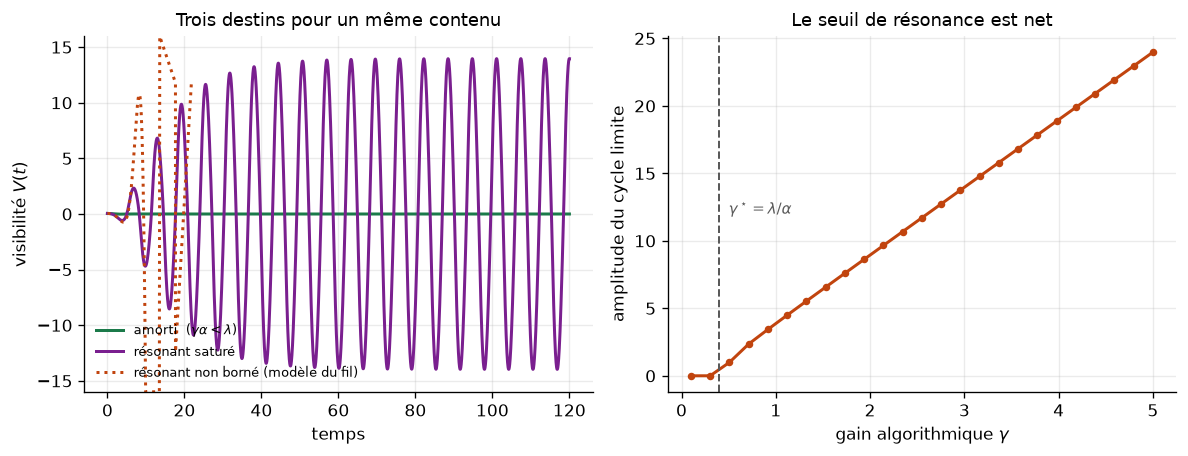

In [3]:
figure, (left, right) = plt.subplots(1, 2, figsize=(10, 3.9))

for (label, solution), colour in zip(
    solutions.items(), [PALETTE["remedy"], PALETTE["field"], PALETTE["disorder"]]
):
    visible = solution.visibility
    if solution.diverged:
        # La branche divergente est tronquée pour rester lisible sur une échelle linéaire.
        keep = np.abs(visible) < 16.0
        left.plot(solution.times[keep], visible[keep], color=colour, linestyle=":", label=label)
    else:
        left.plot(solution.times, visible, color=colour, label=label)

left.set_xlabel("temps")
left.set_ylabel("visibilité $V(t)$")
left.set_ylim(-16.0, 16.0)
left.set_title("Trois destins pour un même contenu")
left.legend(fontsize=8)

right.plot(gains, amplitudes, "o-", color=PALETTE["disorder"], markersize=3.5)
right.axvline(threshold, color=PALETTE["neutral"], linestyle="--", linewidth=1.2)
right.text(threshold + 0.1, amplitudes.max() * 0.5,
           r"$\gamma^\star = \lambda / \alpha$", color=PALETTE["neutral"], fontsize=9)
right.set_xlabel(r"gain algorithmique $\gamma$")
right.set_ylabel("amplitude du cycle limite")
right.set_title("Le seuil de résonance est net")

save_figure(figure, "fig06_resonance.png")
plt.show()

## Ce que le notebook établit

1. Le critère $\gamma\alpha > \lambda$ sépare effectivement les deux régimes, et le
   seuil mesuré coïncide avec $\lambda/\alpha$.
2. Sans saturation, le modèle diverge vers l'infini : il fallait le borner pour qu'il
   décrive quoi que ce soit d'observable. Avec l'attention finie, la fausse
   information ne disparaît pas mais ne submerge pas tout — elle devient un **sujet
   récurrent**, ce qui est le comportement réellement constaté.
3. La charge émotionnelle $\alpha$ suffit à franchir le seuil à gain constant : une
   plateforme n'a **pas besoin de favoriser la désinformation** pour l'amplifier
   sélectivement. Un gain uniforme appliqué à des contenus d'émotivité inégale
   produit mécaniquement ce biais. C'est ce qui rend la mesure de $\gamma$ plus
   pertinente qu'un audit d'intentions.